# IMDB Sentiment Classification

Compare three encoder-style models: **RNN**, **LSTM**, and an **encoder-only Transformer with self-attention**. All use the same preprocessing and training pipeline.

In [14]:
import os, re, time, random
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import kagglehub

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE=64
MAX_LEN=256
MAX_VOCAB_SIZE=30000
MIN_FREQ=2
EMBED_DIM=128
HIDDEN_DIM=128
NUM_LAYERS=2
DROPOUT=0.3
EPOCHS=3
LR=1e-3
PAD_IDX=0
UNK_IDX=1
print("Device:", DEVICE)

Device: cuda


## 1. Download and inspect the dataset

In [2]:
path=kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Path to dataset files:", path)
csv_path=os.path.join(path,"IMDB Dataset.csv")
if not os.path.exists(csv_path):
    csvs=[os.path.join(path,f) for f in os.listdir(path) if f.lower().endswith(".csv")]
    if not csvs: raise FileNotFoundError("No CSV found in downloaded dataset")
    csv_path=csvs[0]
df=pd.read_csv(csv_path)
print(df.shape)
display(df.head())
print(df["sentiment"].value_counts())
print(df.isna().sum())

100%|██████████| 25.7M/25.7M [00:14<00:00, 1.81MB/s]

Extracting files...


Path to dataset files: C:\Users\ADMIN\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1
(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


sentiment
positive    25000
negative    25000
Name: count, dtype: int64
review       0
sentiment    0
dtype: int64


In [3]:
df=df.dropna(subset=["review","sentiment"]).copy()
df["label"]=df["sentiment"].map({"negative":0,"positive":1}).astype(int)
train_df,test_df=train_test_split(df[["review","label"]],test_size=.20,random_state=SEED,stratify=df["label"])
train_df,val_df=train_test_split(train_df,test_size=.125,random_state=SEED,stratify=train_df["label"])
print("Train:",len(train_df),"Val:",len(val_df),"Test:",len(test_df))

Train: 35000 Val: 5000 Test: 10000


## 2. Tokenization, vocabulary, and DataLoaders

The same learned word embedding and tokenization are used by all three models.

In [4]:
def tokenize(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)?|[0-9]+|[^\\w\\s]", text.lower())

counter=Counter()
for text in train_df["review"]: counter.update(tokenize(text))
itos=["<pad>","<unk>"]
for tok,freq in counter.most_common():
    if freq<MIN_FREQ or len(itos)>=MAX_VOCAB_SIZE: break
    itos.append(tok)
stoi={tok:i for i,tok in enumerate(itos)}
print("Vocabulary size:",len(itos))

def encode(text):
    return [stoi.get(t,UNK_IDX) for t in tokenize(text)][:MAX_LEN]

class IMDBDataset(Dataset):
    def __init__(self,frame):
        self.texts=frame.review.tolist()
        self.labels=frame.label.astype(np.int64).tolist()
    def __len__(self): return len(self.labels)
    def __getitem__(self,i): return encode(self.texts[i]),self.labels[i]

def collate(batch):
    seqs,labels=zip(*batch)
    lengths=torch.tensor([len(s) for s in seqs],dtype=torch.long)
    x=nn.utils.rnn.pad_sequence([torch.tensor(s) for s in seqs],batch_first=True,padding_value=PAD_IDX)
    return x,lengths,torch.tensor(labels)

train_loader=DataLoader(IMDBDataset(train_df),batch_size=BATCH_SIZE,shuffle=True,collate_fn=collate)
val_loader=DataLoader(IMDBDataset(val_df),batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate)
test_loader=DataLoader(IMDBDataset(test_df),batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate)

Vocabulary size: 30000


## 3. RNN encoder

In [5]:
class RNNClassifier(nn.Module):
    def __init__(self,vocab,emb,hidden,layers=2,dropout=.3):
        super().__init__()
        self.embedding=nn.Embedding(vocab,emb,padding_idx=PAD_IDX)
        self.rnn=nn.RNN(emb,hidden,num_layers=layers,batch_first=True,dropout=dropout if layers>1 else 0)
        self.drop=nn.Dropout(dropout); self.fc=nn.Linear(hidden,2)
    def forward(self,x,lengths):
        e=self.embedding(x)
        p=nn.utils.rnn.pack_padded_sequence(e,lengths.cpu(),batch_first=True,enforce_sorted=False)
        _,h=self.rnn(p)
        return self.fc(self.drop(h[-1]))

## 4. LSTM encoder

In [6]:
class LSTMClassifier(nn.Module):
    def __init__(self,vocab,emb,hidden,layers=2,dropout=.3):
        super().__init__()
        self.embedding=nn.Embedding(vocab,emb,padding_idx=PAD_IDX)
        self.lstm=nn.LSTM(emb,hidden,num_layers=layers,batch_first=True,dropout=dropout if layers>1 else 0)
        self.drop=nn.Dropout(dropout); self.fc=nn.Linear(hidden,2)
    def forward(self,x,lengths):
        e=self.embedding(x)
        p=nn.utils.rnn.pack_padded_sequence(e,lengths.cpu(),batch_first=True,enforce_sorted=False)
        _,(h,_) = self.lstm(p)
        return self.fc(self.drop(h[-1]))

## 5. Encoder-only Transformer

This is a from-scratch Transformer encoder using multi-head self-attention. There is no decoder. Positional embeddings provide token-order information, and valid encoder outputs are mean-pooled for classification.

In [7]:
class TransformerEncoderClassifier(nn.Module):
    def __init__(self,vocab,emb,nhead=4,layers=2,dropout=.3,max_len=MAX_LEN):
        super().__init__()
        self.embedding=nn.Embedding(vocab,emb,padding_idx=PAD_IDX)
        self.position=nn.Embedding(max_len,emb)
        layer=nn.TransformerEncoderLayer(d_model=emb,nhead=nhead,dim_feedforward=emb*4,dropout=dropout,activation="gelu",batch_first=True,norm_first=True)
        self.encoder=nn.TransformerEncoder(layer,num_layers=layers)
        self.norm=nn.LayerNorm(emb); self.drop=nn.Dropout(dropout); self.fc=nn.Linear(emb,2)
    def forward(self,x,lengths):
        b,s=x.shape
        pos=torch.arange(s,device=x.device).unsqueeze(0).expand(b,-1)
        pad=x.eq(PAD_IDX)
        h=self.embedding(x)+self.position(pos)
        h=self.encoder(h,src_key_padding_mask=pad)
        valid=(~pad).unsqueeze(-1)
        pooled=(h*valid).sum(1)/valid.sum(1).clamp_min(1)
        return self.fc(self.drop(self.norm(pooled)))

## 6. Compare parameter counts

In [8]:
models={
"RNN":RNNClassifier(len(itos),EMBED_DIM,HIDDEN_DIM,NUM_LAYERS,DROPOUT).to(DEVICE),
"LSTM":LSTMClassifier(len(itos),EMBED_DIM,HIDDEN_DIM,NUM_LAYERS,DROPOUT).to(DEVICE),
"Transformer Encoder":TransformerEncoderClassifier(len(itos),EMBED_DIM,4,NUM_LAYERS,DROPOUT).to(DEVICE)
}
for name,m in models.items():
    print(f"{name:22s}: {sum(p.numel() for p in m.parameters() if p.requires_grad):,}")

RNN                   : 3,906,306
LSTM                  : 4,104,450
Transformer Encoder   : 4,269,826


c:\Users\ADMIN\ai_venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 7. Training utilities

In [9]:
def epoch(model,loader,criterion,optimizer=None):
    train=optimizer is not None; model.train(train)
    total=correct=0; loss_sum=0
    with (torch.enable_grad() if train else torch.no_grad()):
        for x,lengths,y in loader:
            x,lengths,y=x.to(DEVICE),lengths.to(DEVICE),y.to(DEVICE)
            if train: optimizer.zero_grad(set_to_none=True)
            logits=model(x,lengths); loss=criterion(logits,y)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
                optimizer.step()
            loss_sum += loss.item()*len(y); correct += (logits.argmax(1)==y).sum().item(); total += len(y)
    return loss_sum/total,correct/total

def train_model(model,name):
    criterion=nn.CrossEntropyLoss()
    opt=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-4)
    hist={"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[]}
    best=-1; best_state=None; start=time.time()
    for ep in range(1,EPOCHS+1):
        tl,ta=epoch(model,train_loader,criterion,opt)
        vl,va=epoch(model,val_loader,criterion)
        for k,v in [("train_loss",tl),("train_acc",ta),("val_loss",vl),("val_acc",va)]: hist[k].append(v)
        if va>best:
            best=va; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        print(f"{name} | epoch {ep}: train acc={ta:.4f}, val acc={va:.4f}")
    model.load_state_dict(best_state)
    return hist,time.time()-start

## 8. Train all three models

In [10]:
histories={}; timings={}
for name,model in models.items():
    histories[name],timings[name]=train_model(model,name)

RNN | epoch 1: train acc=0.5104, val acc=0.5132
RNN | epoch 2: train acc=0.5435, val acc=0.5548
RNN | epoch 3: train acc=0.5788, val acc=0.5472
LSTM | epoch 1: train acc=0.5731, val acc=0.6888
LSTM | epoch 2: train acc=0.7646, val acc=0.7918
LSTM | epoch 3: train acc=0.8491, val acc=0.8292
Transformer Encoder | epoch 1: train acc=0.6991, val acc=0.7976
Transformer Encoder | epoch 2: train acc=0.8240, val acc=0.7892
Transformer Encoder | epoch 3: train acc=0.8670, val acc=0.8262


## 9. Training curves

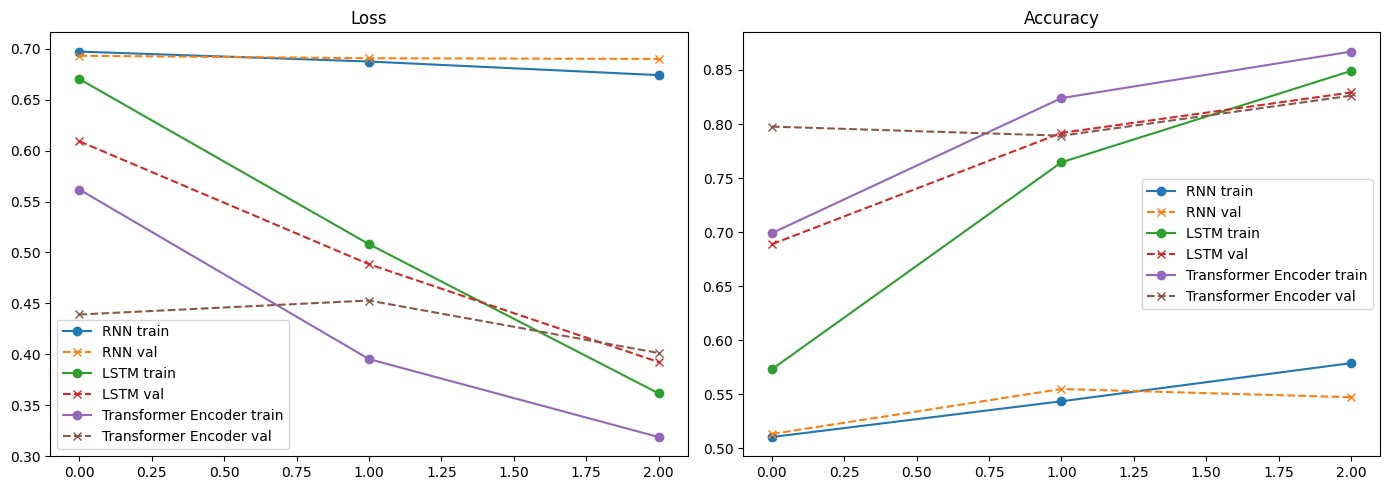

In [11]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
for name,h in histories.items():
    ax[0].plot(h["train_loss"],marker="o",label=name+" train")
    ax[0].plot(h["val_loss"],marker="x",linestyle="--",label=name+" val")
    ax[1].plot(h["train_acc"],marker="o",label=name+" train")
    ax[1].plot(h["val_acc"],marker="x",linestyle="--",label=name+" val")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].set_title("Accuracy"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Test-set metrics

In [15]:
def predict(model, loader):
    model.eval()
    ys = []
    ps = []

    with torch.no_grad():
        for x, lengths, y in loader:
            logits = model(
                x.to(DEVICE),
                lengths.to(DEVICE)
            )

            ps.extend(logits.argmax(1).cpu().numpy())
            ys.extend(y.numpy())

    return np.array(ys), np.array(ps)


rows = []

for name, model in models.items():
    y, p = predict(model, test_loader)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y,
        p,
        average="binary",
        zero_division=0
    )

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y, p),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Train time (min)": timings[name] / 60
    })

    print("\n", name)

    print(
        classification_report(
            y,
            p,
            target_names=["negative", "positive"],
            digits=4
        )
    )

results_df = pd.DataFrame(rows)

display(results_df)


 RNN
              precision    recall  f1-score   support

    negative     0.5499    0.6874    0.6110      5000
    positive     0.5832    0.4374    0.4999      5000

    accuracy                         0.5624     10000
   macro avg     0.5666    0.5624    0.5555     10000
weighted avg     0.5666    0.5624    0.5555     10000


 LSTM
              precision    recall  f1-score   support

    negative     0.8516    0.8276    0.8394      5000
    positive     0.8323    0.8558    0.8439      5000

    accuracy                         0.8417     10000
   macro avg     0.8420    0.8417    0.8417     10000
weighted avg     0.8420    0.8417    0.8417     10000


 Transformer Encoder
              precision    recall  f1-score   support

    negative     0.8792    0.7742    0.8234      5000
    positive     0.7983    0.8936    0.8433      5000

    accuracy                         0.8339     10000
   macro avg     0.8387    0.8339    0.8333     10000
weighted avg     0.8387    0.8339    0.

,Model,Accuracy,Precision,Recall,F1,Train time (min)
0,RNN,0.5624,0.583200,0.4374,0.499886,1.839577
1,LSTM,0.8417,0.832328,0.8558,0.843901,2.111328
2,Transformer Encoder,0.8339,0.798285,0.8936,0.843258,2.576180


## 11. Confusion matrices

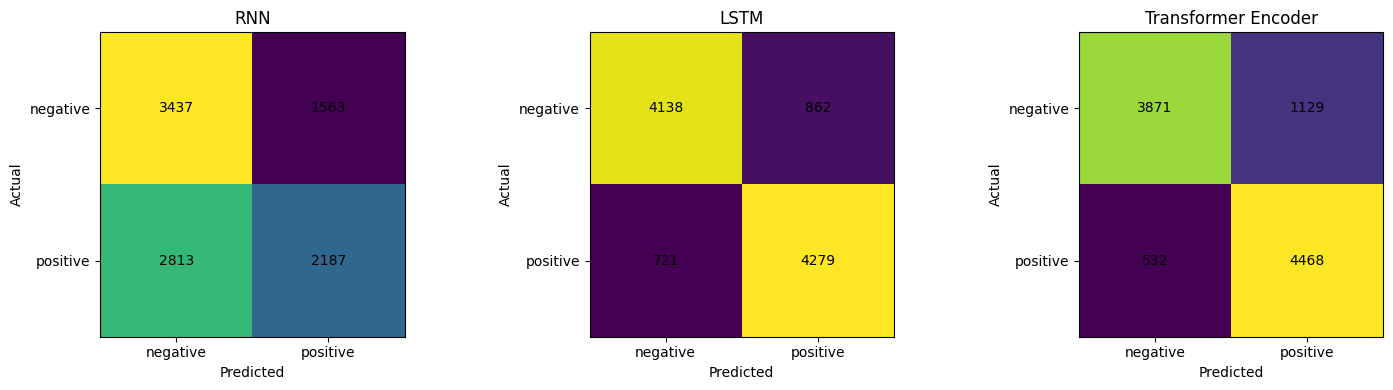

In [16]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(name,model) in zip(axes,models.items()):
    y,p=predict(model,test_loader); cm=confusion_matrix(y,p)
    ax.imshow(cm); ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticks([0,1],["negative","positive"]); ax.set_yticks([0,1],["negative","positive"])
    for i in range(2):
        for j in range(2): ax.text(j,i,cm[i,j],ha="center",va="center")
plt.tight_layout(); plt.show()

## 12. Custom review prediction

In [20]:
def predict_text(text):
    ids=encode(text)
    if not ids: raise ValueError("No recognized tokens.")
    x=torch.tensor([ids],dtype=torch.long,device=DEVICE)
    lengths=torch.tensor([len(ids)],dtype=torch.long,device=DEVICE)
    print("Review:",text)
    for name,model in models.items():
        model.eval()
        with torch.no_grad(): probs=torch.softmax(model(x,lengths),1)[0]
        label="positive" if probs[1]>=probs[0] else "negative"
        print(f"{name:22s}: {label:8s} | negative={probs[0]:.3f}, positive={probs[1]:.3f}")

predict_text("I did not love the movie")

Review: I did not love the movie
RNN                   : negative | negative=0.699, positive=0.301
LSTM                  : positive | negative=0.298, positive=0.702
Transformer Encoder   : positive | negative=0.006, positive=0.994


## 13. Interpretation

**RNN** processes tokens sequentially and compresses the past into a hidden state. **LSTM** keeps recurrence but adds gates and a cell state. **Transformer Encoder** uses self-attention, allowing tokens to interact directly across the sequence.

This notebook intentionally uses **from-scratch embeddings and models**. A pretrained BERT-style encoder would be a separate experiment because pretraining contributes substantial external language knowledge.